In [1]:
import tensorflow as tf
(x_train,y_train),(x_test,y_test)= tf.keras.datasets.cifar100.load_data()

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 46s 0us/step


In [2]:
x_train.shape

(50000, 32, 32, 3)

In [3]:
x_test.shape

(10000, 32, 32, 3)

In [4]:
x_train = x_train.reshape(x_train.shape[0],32,32,3)
x_test = x_test.reshape(x_test.shape[0],32,32,3)
input_shape = (32,32,3)

In [5]:
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')

In [6]:
x_train /= 255 # mandatory step to normalize the pixel of image from 0 -255 to 0-1 range
x_test /= 255

In [11]:
#model creation
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    tf.keras.layers.MaxPooling2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dense(100, activation='softmax') 
])

In [12]:
# 2. Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [13]:
history = model.fit(x_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 39s 23ms/step - accuracy: 0.1738 - loss: 3.5578
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.2942 - loss: 2.8741
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.3442 - loss: 2.6019
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.3874 - loss: 2.3994
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.4236 - loss: 2.2335
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.4574 - loss: 2.0818
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.4877 - loss: 1.9364
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 23ms/step - accuracy: 0.5202 - loss: 1.8027
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 37s 24ms/step - accuracy: 0.5509 - loss: 1.6710
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 36s 23ms/step - accuracy: 0.5811 - loss: 1.5441


In [14]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.3293 - loss: 2.9893


[2.9893476963043213, 0.3292999863624573]

In [15]:
#predicting the labels_digit
y_predict = model.predict(x_test)
y_predict

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step


array([[2.5464280e-07, 1.4363322e-06, 6.9741243e-03, ..., 1.2961202e-04,
        4.7601573e-03, 1.5683571e-02],
       [1.1428630e-05, 4.6401918e-03, 1.1866085e-02, ..., 1.7984189e-02,
        8.7241922e-04, 1.0202052e-02],
       [6.5475285e-07, 6.1676925e-05, 6.2434192e-05, ..., 4.2603938e-06,
        3.9195824e-05, 1.2866883e-04],
       ...,
       [1.7060722e-06, 6.7312835e-04, 2.2498525e-05, ..., 1.5696845e-03,
        4.3623163e-06, 4.2347968e-04],
       [1.3563694e-06, 1.0649266e-05, 3.4587268e-02, ..., 1.8965146e-04,
        2.3889876e-04, 5.3118949e-04],
       [9.2725364e-05, 1.7252880e-04, 1.7867201e-03, ..., 1.8664861e-10,
        2.0291896e-05, 3.0844424e-07]], shape=(10000, 100), dtype=float32)

In [16]:
#Here we get the index of maximum value in the encoded vector.
import numpy as np
y_predicts = np.argmax(y_predict,axis=1)

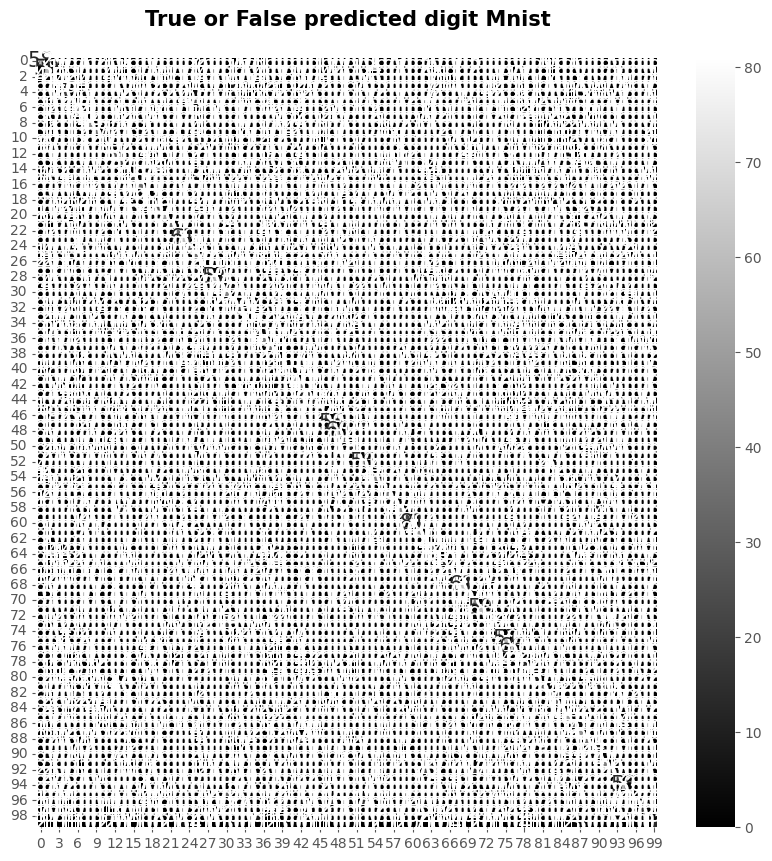

In [17]:
#Confusion matrix for digit mnist
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
con_mat = confusion_matrix(y_test,y_predicts)
plt.style.use('ggplot')
plt.figure(figsize=(10,10))
sns.heatmap(con_mat,annot=True,annot_kws={'size':15},linewidths=0.5,fmt='d',cmap='gray')
plt.title('True or False predicted digit Mnist\n', fontweight='bold',fontsize=15)
plt.show()

In [18]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_predicts))

              precision    recall  f1-score   support

           0       0.61      0.58      0.59       100
           1       0.35      0.59      0.44       100
           2       0.16      0.25      0.20       100
           3       0.11      0.04      0.06       100
           4       0.16      0.19      0.17       100
           5       0.24      0.20      0.22       100
           6       0.28      0.46      0.34       100
           7       0.33      0.48      0.39       100
           8       0.62      0.44      0.51       100
           9       0.62      0.37      0.46       100
          10       0.25      0.21      0.23       100
          11       0.26      0.19      0.22       100
          12       0.26      0.31      0.28       100
          13       0.24      0.22      0.23       100
          14       0.26      0.21      0.23       100
          15       0.39      0.18      0.25       100
          16       0.47      0.35      0.40       100
          17       0.39    

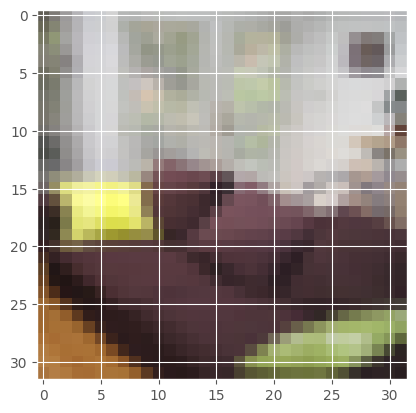

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
Predicted: 25
Actual: 25


In [19]:
image_index = 3072


plt.imshow(x_test[image_index])
plt.show()


img = x_test[image_index].reshape(1, 32, 32, 3)

pred = model.predict(img)
predicted_class = np.argmax(pred, axis=1)[0]

print("Predicted:", predicted_class)
print("Actual:", y_test[image_index][0])